In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [2]:
# Membuat data dummy
np.random.seed(0)
data_normal = np.random.normal(loc=50, scale=200, size=2000)  # Data normal
data_outliers = np.append(data_normal, [2500, 3500, 4000])  # Menambahkan outlier

In [3]:
# Membuat DataFrame
df = pd.DataFrame(data_outliers, columns=['Value'])

In [4]:
df.sample(3)

,Value
1013,362.680949
116,239.450394
1167,125.551834


In [5]:
df.shape

(2003, 1)

In [6]:
# Calculating Z-score value
df['Z-Score'] = zscore(df['Value'])

In [7]:
df

,Value,Z-Score
0,402.810469,1.497650
1,130.031442,0.333927
2,245.747597,0.827592
3,498.178640,1.904507
4,423.511598,1.585965
...,...,...
1998,-178.380284,-0.981812
1999,-212.194074,-1.126068
2000,2500.000000,10.444630
2001,3500.000000,14.710806


In [8]:
# Menentukan outlier (nilai Z-Score > 3 atau < -3)
outliers = df[df['Z-Score'].abs() > 3]
print("Outliers Detected:\n", outliers)

Outliers Detected:
        Value    Z-Score
2000  2500.0  10.444630
2001  3500.0  14.710806
2002  4000.0  16.843894


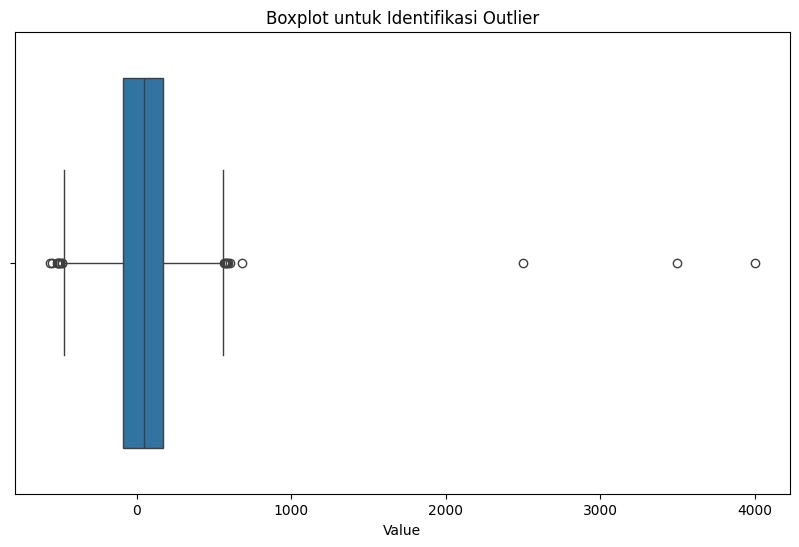

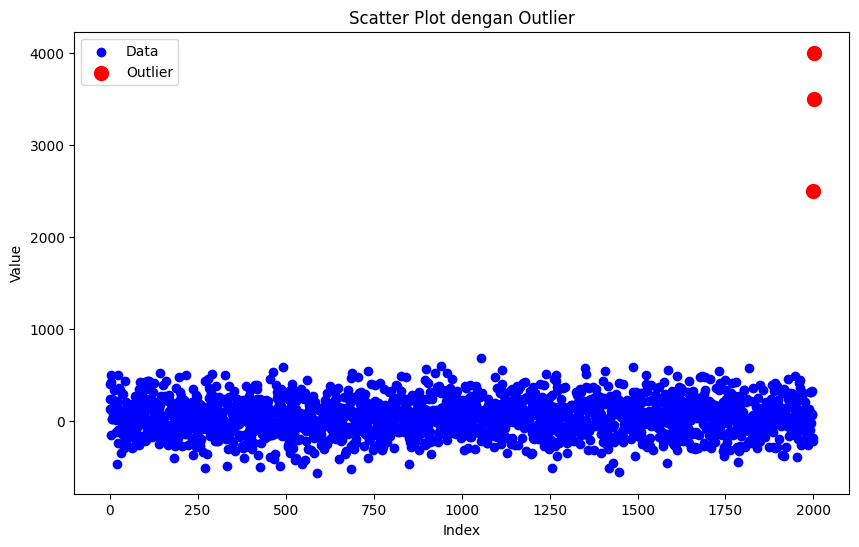

In [9]:
# Visualisasi menggunakan Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Value'])
plt.title('Boxplot untuk Identifikasi Outlier')
plt.show()

# Visualisasi menggunakan Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['Value'], label='Data', color='blue')

# Menambahkan outlier ke plot
plt.scatter(outliers.index, outliers['Value'], color='red', label='Outlier', s=100)
plt.title('Scatter Plot dengan Outlier')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()

Penjelasan:
- Boxplot: Boxplot menunjukkan distribusi data dan memberikan indikasi outlier (biasanya data yang berada di luar batas box).
- Scatter Plot: Scatter plot membantu kita melihat bagaimana data tersebar, dengan outlier yang ditandai dengan warna merah.

#### Outlier Handling

In [10]:
# Imputasi outlier dengan median
median_value = df['Value'].median()
df['Imputed Value'] = df['Value'].apply(lambda x: median_value if abs(zscore([x])) > 3 else x)

In [11]:
median_value

np.float64(47.02845932905946)

In [12]:
# Menampilkan hasil imputasi
print("Data setelah imputasi:\n", df[['Value', 'Imputed Value']].head())

Data setelah imputasi:
         Value  Imputed Value
0  402.810469     402.810469
1  130.031442     130.031442
2  245.747597     245.747597
3  498.178640     498.178640
4  423.511598     423.511598
